<a href="https://colab.research.google.com/github/edwardoughton/IGARSS26/blob/main/notebook_2_congo_river_water_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ IGARSS 2026 Summer School 🛰️
## AI Refusnik to AI Evangelist: Excelling at AI-Assisted Coding for Satellite Image Analysis

**Instructor:** Ed Oughton, George Mason University

**Session duration:** ~60 minutes

**AI usage statement:** AI was used to support notebook code generation, but all content is based on my original GMU GGS course (https://github.com/edwardoughton/satellite-image-analysis/)

---

## Bolobo, DRC, water-occurrence map for route planning

This notebook details a recent problem I have been working on for the Congo River, DRC. The approach is to use Sentinel-2 to extract NDWI pixels and then create a water-occurrence map as a surface-water screening proxy to plan boat survey routes for a new fiber-optic cable.

The concern is that shallow areas of the river may expose boat propellers to hazards during the dry season, so we need to identify where the deepest water may be. This is not bathymetric data and does not prove that a cable corridor is safe, but it provides a useful initial guide for the survey boat.


## Learning Objectives

1. Load prepared Area of Interest (AOI) Sentinel-2 water and valid-pixel masks.
2. Develop a pixel inventory and stack every prepared Sentinel-2 observation from 2022-2025.
3. Estimate water occurrence for an initial section of river, but across the full corridor.
4. Export a map and GIS-ready rasters for interpretation.


## 1. Install Dependencies

For this initial demo, only the compact, classified masks are required. The original Sentinel-2 band imagery is not loaded. `contextily` provides the optional online basemap and `geopandas` supports other GIS functions.

### Minimal `bolobo_pilot` data input bundle

Required for the calculation:

- `download_log_sentinel-2.csv` (24 KB)
- `masks/sentinel-2/<scene>/<scene>_whole_aoi_valid.tif` for all 12 scenes
- `masks/sentinel-2/<scene>/<scene>_whole_aoi_water.tif` for all 12 scenes

Optional:

- `context/ne_110m_admin_0_countries.zip` adds the Africa location inset.
- `sentinel2_wet_occurrence.tif` validates the calculation against the pilot result.

OpenStreetMap tiles are fetched online and are not stored here.


In [12]:
# Run once in Google Colab. Restarting the runtime is normally unnecessary.
%pip -q install rasterio geopandas pyogrio rioxarray xarray contextily


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [13]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import transform_bounds
import rioxarray  # activates the .rio accessor

import geopandas as gpd
warnings.filterwarnings("ignore")

PILOT_DIR = Path("bolobo_pilot")
MASK_DIR = PILOT_DIR / "masks" / "sentinel-2"
DOWNLOAD_LOG_PATH = PILOT_DIR / "download_log_sentinel-2.csv"
CONTEXT_DIR = PILOT_DIR / "context"
DATA_DIR = Path("data/bolobo_water_probability")
DATA_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [PILOT_DIR, MASK_DIR, DOWNLOAD_LOG_PATH]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required Bolobo pilot inputs: {missing}")

print("Inputs:", PILOT_DIR.resolve())
print("Outputs:", DATA_DIR.resolve())


Inputs: /Users/l25-n05970-exp/Desktop/GitHub/igarss26/bolobo_pilot
Outputs: /Users/l25-n05970-exp/Desktop/GitHub/igarss26/data/bolobo_water_probability


## 2. Configure the Bolobo Whole-River Run

The analysis uses `*_whole_aoi_valid.tif` and `*_whole_aoi_water.tif` files. These cover the broad river scene rather than the route line.


In [14]:
AOI_NAME = "Bolobo, DRC"
YEARS = list(range(2022, 2026))
# Use every prepared scene to reproduce the pilot result exactly. Set this to an
# integer (for example, 1) to keep only the least-cloudy N scenes per year.
SCENES_PER_YEAR = None
MIN_VALID_OBSERVATIONS = 1
EXPORT_NETCDF = False  # The uncompressed summary is about 208 MB.

print(AOI_NAME)
print("Years:", YEARS)
print("Scenes per year:", SCENES_PER_YEAR or "all available")


Bolobo, DRC
Years: [2022, 2023, 2024, 2025]
Scenes per year: all available


## 3. Inventory the Whole-AOI Mask Pairs

The pilot folder contains 12 prepared Sentinel-2 mask pairs. By default we retain every pair because the supplied reference occurrence raster was calculated from all 12. The optional `SCENES_PER_YEAR` setting can be used to create a faster, more approximate run, if desired.


In [15]:
download_log = pd.read_csv(DOWNLOAD_LOG_PATH)
download_log["datetime"] = pd.to_datetime(download_log["datetime"], utc=True)
download_log["year"] = download_log["datetime"].dt.year

available_masks = []
for scene_dir in sorted(MASK_DIR.iterdir()):
    if not scene_dir.is_dir():
        continue
    item_id = scene_dir.name[9:]
    valid_path = scene_dir / f"{scene_dir.name}_whole_aoi_valid.tif"
    water_path = scene_dir / f"{scene_dir.name}_whole_aoi_water.tif"
    if valid_path.exists() and water_path.exists():
        available_masks.append(
            {
                "item_id": item_id,
                "scene_dir": scene_dir,
                "valid_mask_path": valid_path,
                "water_mask_path": water_path,
            }
        )

available_masks = pd.DataFrame(available_masks)
if available_masks.empty:
    raise RuntimeError("No whole-AOI Sentinel-2 water/valid mask pairs were found.")

scene_inventory = (
    download_log.groupby(["year", "item_id", "datetime", "cloud_cover"], as_index=False)
    .agg(available_assets=("asset", "nunique"))
    .merge(available_masks, on="item_id", how="inner")
    .sort_values(["year", "cloud_cover", "datetime", "item_id"])
)

selected_scene_inventory = scene_inventory.loc[
    scene_inventory["year"].isin(YEARS)
].copy()
if SCENES_PER_YEAR is not None:
    selected_scene_inventory = (
        selected_scene_inventory.groupby("year", group_keys=False)
        .head(SCENES_PER_YEAR)
    )
selected_scene_inventory = (
    selected_scene_inventory.sort_values(["datetime", "cloud_cover", "item_id"])
    .reset_index(drop=True)
)

missing_years = sorted(set(YEARS) - set(selected_scene_inventory["year"]))
if missing_years:
    raise RuntimeError(f"No local whole-AOI mask pair is available for years: {missing_years}")

scene_inventory.to_csv(DATA_DIR / "bolobo_whole_aoi_scene_inventory.csv", index=False)
selected_scene_inventory.to_csv(DATA_DIR / "bolobo_whole_aoi_selected_scene_inventory.csv", index=False)

display(
    selected_scene_inventory[
        ["year", "datetime", "cloud_cover", "item_id", "valid_mask_path", "water_mask_path"]
    ]
)
print("Selected whole-AOI mask pairs:", len(selected_scene_inventory))


,year,datetime,cloud_cover,item_id,valid_mask_path,water_mask_path
0,2022,2022-06-11 08:55:59.024000+00:00,0.008079,S2B_MSIL2A_20220611T085559_R007_T33MXT_2022061...,bolobo_pilot/masks/sentinel-2/20220611_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20220611_S2B_MSI...
1,2022,2022-06-11 08:55:59.024000+00:00,0.008175,S2B_MSIL2A_20220611T085559_R007_T33MXT_2024062...,bolobo_pilot/masks/sentinel-2/20220611_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20220611_S2B_MSI...
2,2022,2022-08-10 08:55:59.024000+00:00,0.198374,S2B_MSIL2A_20220810T085559_R007_T33MXT_2022081...,bolobo_pilot/masks/sentinel-2/20220810_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20220810_S2B_MSI...
3,2022,2022-08-10 08:55:59.024000+00:00,0.199395,S2B_MSIL2A_20220810T085559_R007_T33MXT_2024071...,bolobo_pilot/masks/sentinel-2/20220810_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20220810_S2B_MSI...
4,2023,2023-07-06 08:55:59.024000+00:00,0.269485,S2B_MSIL2A_20230706T085559_R007_T33MXT_2023070...,bolobo_pilot/masks/sentinel-2/20230706_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20230706_S2B_MSI...
5,2024,2024-06-20 08:55:59.024000+00:00,0.351236,S2B_MSIL2A_20240620T085559_R007_T33MXT_2024062...,bolobo_pilot/masks/sentinel-2/20240620_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20240620_S2B_MSI...
6,2024,2024-08-09 08:55:59.024000+00:00,0.100202,S2B_MSIL2A_20240809T085559_R007_T33MXT_2024080...,bolobo_pilot/masks/sentinel-2/20240809_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20240809_S2B_MSI...
7,2025,2025-07-22 09:15:41.024000+00:00,0.000000,S2A_MSIL2A_20250722T091541_R007_T33MXT_2025072...,bolobo_pilot/masks/sentinel-2/20250722_S2A_MSI...,bolobo_pilot/masks/sentinel-2/20250722_S2A_MSI...
8,2025,2025-08-04 08:55:59.024000+00:00,0.005464,S2B_MSIL2A_20250804T085559_R007_T33MXT_2025080...,bolobo_pilot/masks/sentinel-2/20250804_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20250804_S2B_MSI...
9,2025,2025-08-14 08:55:59.024000+00:00,0.171791,S2B_MSIL2A_20250814T085559_R007_T33MXT_2025081...,bolobo_pilot/masks/sentinel-2/20250814_S2B_MSI...,bolobo_pilot/masks/sentinel-2/20250814_S2B_MSI...


Selected whole-AOI mask pairs: 12


## 4. Load the Whole-AOI Masks

This is the reproducible fast path, so we can stack the 12 prepared binary raster pairs instead of reloading and reclassifying the original Sentinel-2 reflectance bands.


In [16]:
def pixel_centers(transform, width, height):
    x = transform.c + (np.arange(width) + 0.5) * transform.a
    y = transform.f + (np.arange(height) + 0.5) * transform.e
    return x, y


valid_layers = []
water_layers = []
times = []
years = []
analysis_transform = None
analysis_crs = None
x_coords = None
y_coords = None

for _, scene in selected_scene_inventory.iterrows():
    with rasterio.open(scene["valid_mask_path"]) as valid_src:
        valid_raw = valid_src.read(1)
        valid_nodata = valid_src.nodata
        transform = valid_src.transform
        crs = valid_src.crs
        shape_2d = valid_raw.shape

    with rasterio.open(scene["water_mask_path"]) as water_src:
        water_raw = water_src.read(1)
        if water_raw.shape != shape_2d or water_src.transform != transform:
            raise RuntimeError(f"Mask grids do not match for {scene['item_id']}")

    if analysis_transform is None:
        analysis_transform = transform
        analysis_crs = crs
        x_coords, y_coords = pixel_centers(transform, shape_2d[1], shape_2d[0])
    elif shape_2d != (len(y_coords), len(x_coords)) or transform != analysis_transform:
        raise RuntimeError("Selected mask grids do not match. Align masks before stacking.")

    valid = valid_raw == 1
    if valid_nodata is not None:
        valid &= valid_raw != valid_nodata
    water = (water_raw == 1) & valid

    valid_layers.append(valid.astype("uint8"))
    water_layers.append(water.astype("uint8"))
    times.append(scene["datetime"])
    years.append(int(scene["year"]))

valid_stack = xr.DataArray(
    np.stack(valid_layers, axis=0),
    coords={"time": times, "year": ("time", years), "y": y_coords, "x": x_coords},
    dims=("time", "y", "x"),
    name="valid",
)
water_stack = xr.DataArray(
    np.stack(water_layers, axis=0),
    coords=valid_stack.coords,
    dims=valid_stack.dims,
    name="water",
)

valid_stack = valid_stack.rio.write_crs(analysis_crs).rio.set_spatial_dims(x_dim="x", y_dim="y")
water_stack = water_stack.rio.write_crs(analysis_crs).rio.set_spatial_dims(x_dim="x", y_dim="y")

print("Time steps:", valid_stack.sizes["time"])
print("Raster shape:", valid_stack.sizes["y"], "rows x", valid_stack.sizes["x"], "columns")
print("CRS:", analysis_crs)
print("Pixels with at least one valid observation:", int((valid_stack.sum(dim="time") > 0).sum().item()))


Time steps: 12
Raster shape: 4522 rows x 4014 columns
CRS: EPSG:32733
Pixels with at least one valid observation: 5920238


## 5. Estimate Water-Occurrence Probability

For each pixel, water probability is:

`water observations / valid observations`


In [23]:
valid_count = valid_stack.sum(dim="time").astype("uint16")
water_count = water_stack.sum(dim="time").astype("uint16")
water_probability = (
    water_count / valid_count.where(valid_count > 0)
).astype("float32")

water_probability_reliable = water_probability.where(valid_count >= MIN_VALID_OBSERVATIONS)

summary_ds = xr.Dataset(
    {
        "valid_observation_count": valid_count,
        "water_observation_count": water_count,
        "water_probability": water_probability,
        "water_probability_reliable": water_probability_reliable,
    }
)
summary_ds = summary_ds.rio.write_crs(analysis_crs).rio.set_spatial_dims(x_dim="x", y_dim="y")

# The pilot includes the original result, so verify the all-scene calculation.
reference_path = PILOT_DIR / "sentinel2_wet_occurrence.tif"
if SCENES_PER_YEAR is None and reference_path.exists():
    with rasterio.open(reference_path) as reference_src:
        reference = reference_src.read(1, masked=True)
        same_grid = (
            reference_src.shape == water_probability.shape
            and reference_src.crs == analysis_crs
            and reference_src.transform == analysis_transform
        )
    calculated = water_probability.values
    comparable = ~np.ma.getmaskarray(reference)
    exact_match = same_grid and np.allclose(
        calculated[comparable], reference.data[comparable], atol=1e-7
    )
    if not exact_match:
        raise AssertionError("Calculated occurrence does not match the pilot reference.")
    print("Validation passed: calculation matches sentinel2_wet_occurrence.tif.")

summary_ds


Validation passed: calculation matches sentinel2_wet_occurrence.tif.


<xarray.Dataset> Size: 218MB
Dimensions:                     (y: 4522, x: 4014)
Coordinates:
  * y                           (y) float64 36kB 9.785e+06 ... 9.74e+06
  * x                           (x) float64 32kB 6.216e+05 ... 6.618e+05
    spatial_ref                 int64 8B 0
Data variables:
    valid_observation_count     (y, x) uint16 36MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    water_observation_count     (y, x) uint16 36MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    water_probability           (y, x) float32 73MB nan nan nan ... nan nan nan
    water_probability_reliable  (y, x) float32 73MB nan nan nan ... nan nan nan

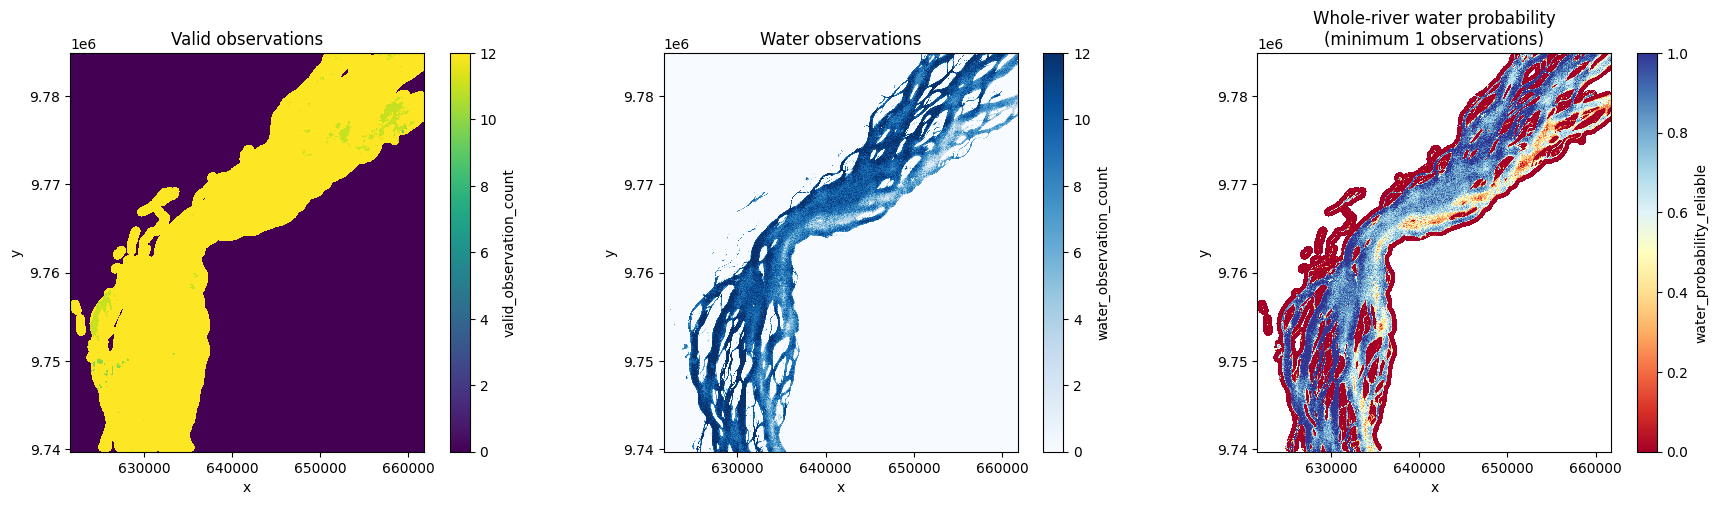

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary_ds["valid_observation_count"].plot.imshow(ax=axes[0], cmap="viridis")
axes[0].set_title("Valid observations")

summary_ds["water_observation_count"].plot.imshow(ax=axes[1], cmap="Blues")
axes[1].set_title("Water observations")

summary_ds["water_probability_reliable"].plot.imshow(
    ax=axes[2], cmap="RdYlBu", vmin=0, vmax=1
)
axes[2].set_title(
    f"Whole-river water probability\n(minimum {MIN_VALID_OBSERVATIONS} observations)"
)

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()


## 6. Compare Annual Whole-AOI Classifications

Each panel shows the selected whole-AOI water mask for one year.


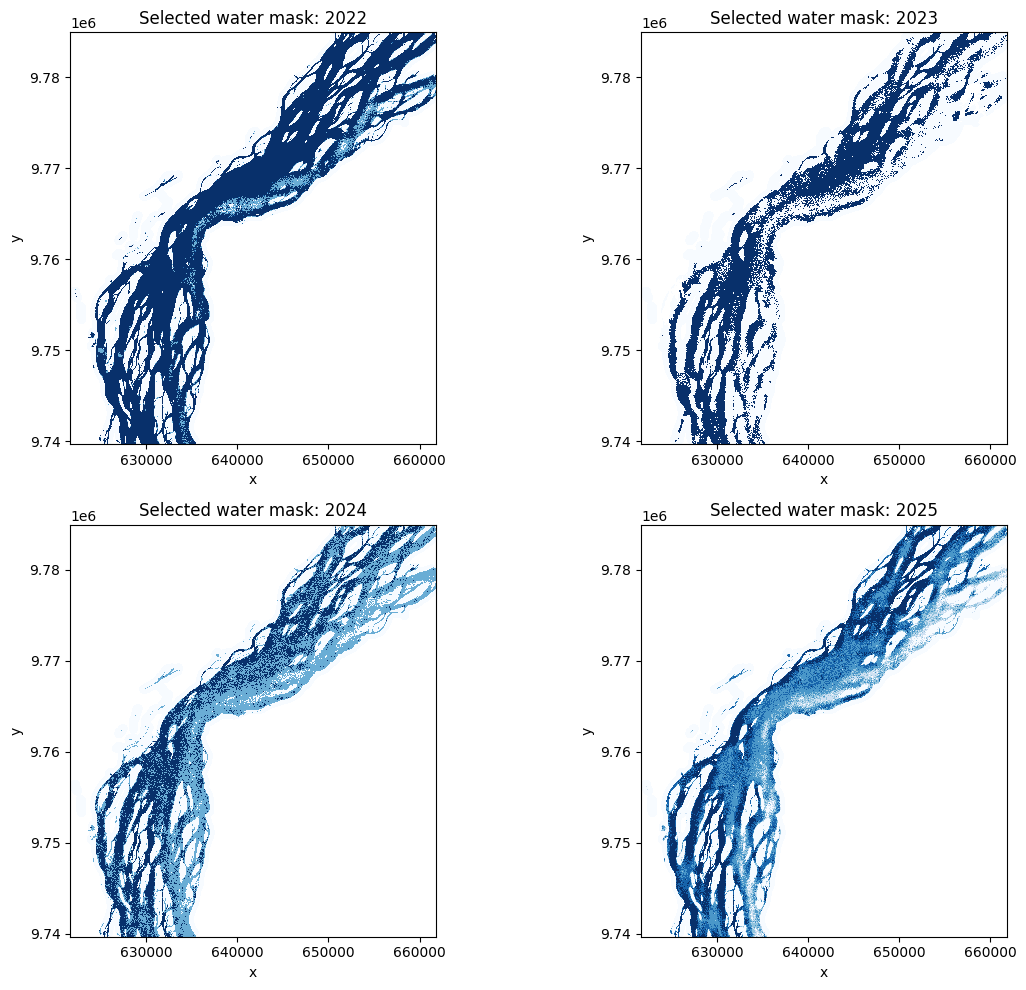

In [19]:
water_by_year = water_stack.groupby("year").mean(dim="time", skipna=True)
valid_by_year = valid_stack.groupby("year").sum(dim="time")
water_by_year = water_by_year.where(valid_by_year >= 1)

n_years = water_by_year.sizes["year"]
ncols = 2
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, year in zip(axes, water_by_year.year.values):
    water_by_year.sel(year=year).plot.imshow(
        ax=ax, cmap="Blues", vmin=0, vmax=1, add_colorbar=False
    )
    ax.set_title(f"Selected water mask: {int(year)}")
    ax.set_aspect("equal")

for ax in axes[n_years:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Make the Publication-Style Whole-River Map

This cell saves a map similar to the example: broad river coverage, red-to-blue occurrence colors, optional OpenStreetMap basemap, colorbar, and a small location inset.


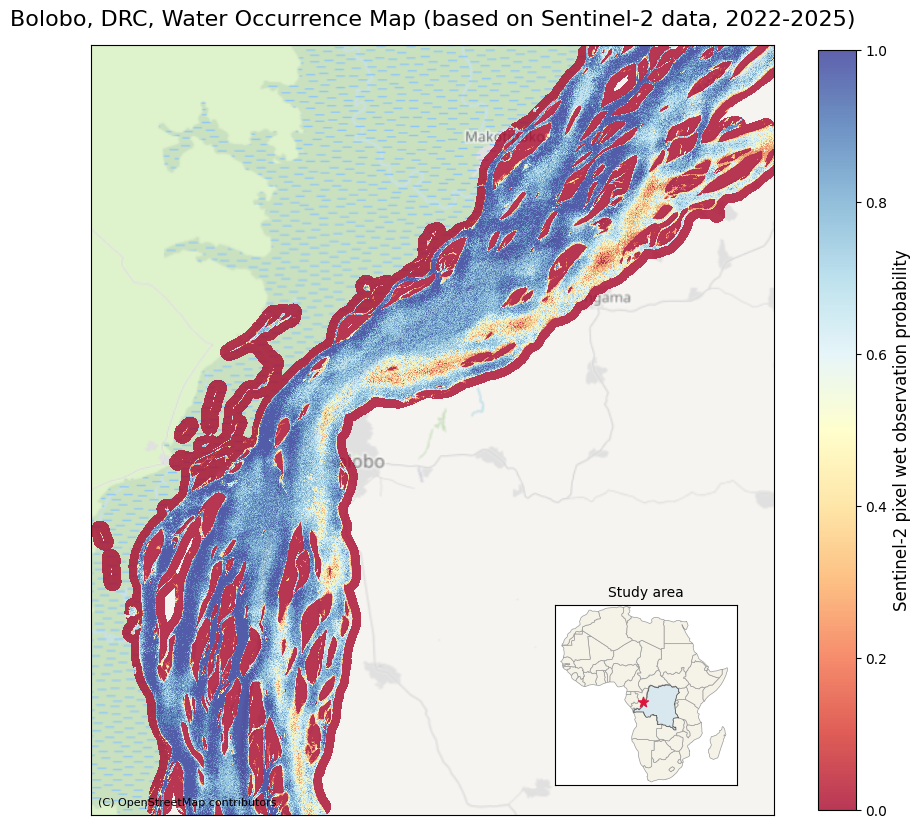

Saved: data/bolobo_water_probability/bolobo_whole_river_water_occurrence_map.png


In [20]:
def add_optional_basemap(ax, crs):
    try:
        import contextily as cx

        cx.add_basemap(
            ax,
            crs=crs,
            source=cx.providers.OpenStreetMap.Mapnik,
            attribution=False,
            alpha=0.65,
        )
        ax.text(
            0.01,
            0.01,
            "(C) OpenStreetMap contributors",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
            ha="left",
            va="bottom",
        )
    except Exception as exc:
        print("Basemap skipped:", exc)
        ax.set_facecolor("#f3f1ea")


def add_location_inset(fig, center_lon, center_lat):
    inset_ax = fig.add_axes([0.66, 0.14, 0.18, 0.18])
    countries_path = CONTEXT_DIR / "ne_110m_admin_0_countries.zip"
    if not countries_path.exists():
        inset_ax.axis("off")
        return
    try:
        countries = gpd.read_file(countries_path).to_crs("EPSG:4326")
        africa = countries.loc[countries["CONTINENT"] == "Africa"]
        drc = countries.loc[
            countries["NAME"].isin(["Dem. Rep. Congo", "Democratic Republic of the Congo"])
        ]
        africa.plot(ax=inset_ax, color="#f5f2e8", edgecolor="#9a9a9a", linewidth=0.5)
        if len(drc):
            drc.plot(ax=inset_ax, color="#d9e7ef", edgecolor="#555555", linewidth=0.6)
        inset_ax.scatter(center_lon, center_lat, marker="*", s=55, color="crimson", zorder=5)
        inset_ax.set_xlim(-20, 55)
        inset_ax.set_ylim(-36, 38)
        inset_ax.set_title("Study area", fontsize=10)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        for spine in inset_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
    except Exception as exc:
        print("Inset skipped:", exc)
        inset_ax.axis("off")


plot_da = summary_ds["water_probability_reliable"]
plot_bounds_wgs84 = transform_bounds(
    analysis_crs,
    "EPSG:4326",
    float(plot_da.x.min()),
    float(plot_da.y.min()),
    float(plot_da.x.max()),
    float(plot_da.y.max()),
    densify_pts=21,
)
center_lon = (plot_bounds_wgs84[0] + plot_bounds_wgs84[2]) / 2
center_lat = (plot_bounds_wgs84[1] + plot_bounds_wgs84[3]) / 2

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(float(plot_da.x.min()), float(plot_da.x.max()))
ax.set_ylim(float(plot_da.y.min()), float(plot_da.y.max()))
add_optional_basemap(ax, analysis_crs)

image = plot_da.plot.imshow(
    ax=ax,
    cmap="RdYlBu",
    vmin=0,
    vmax=1,
    alpha=0.78,
    add_colorbar=False,
)

cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Sentinel-2 pixel wet observation probability", fontsize=12)

ax.set_title(
    "Bolobo, DRC, Water Occurrence Map (based on Sentinel-2 data, 2022-2025)",
    fontsize=16,
    pad=14,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

add_location_inset(fig, center_lon, center_lat)

output_png = DATA_DIR / "bolobo_whole_river_water_occurrence_map.png"
plt.savefig(output_png, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", output_png)


## 8. Export GIS Products

In [21]:
def write_geotiff(data_array, path, dtype="float32", nodata=-9999):
    da = data_array.rio.write_crs(analysis_crs, inplace=False)
    da = da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)

    is_float = np.issubdtype(np.dtype(dtype), np.floating)
    output_nodata = nodata if is_float else 0
    encoded = da.fillna(output_nodata).astype(dtype)
    encoded = encoded.rio.write_nodata(output_nodata, inplace=False)

    encoded.rio.to_raster(
        path,
        driver="GTiff",
        compress="DEFLATE",
        tiled=True,
    )
    print("Wrote:", path)


write_geotiff(
    summary_ds["water_probability_reliable"],
    DATA_DIR / "bolobo_whole_river_water_probability.tif",
)
write_geotiff(
    summary_ds["valid_observation_count"],
    DATA_DIR / "bolobo_whole_river_valid_observation_count.tif",
    dtype="uint16",
    nodata=0,
)
write_geotiff(
    summary_ds["water_observation_count"],
    DATA_DIR / "bolobo_whole_river_water_observation_count.tif",
    dtype="uint16",
    nodata=0,
)


Wrote: data/bolobo_water_probability/bolobo_whole_river_water_probability.tif
Wrote: data/bolobo_water_probability/bolobo_whole_river_valid_observation_count.tif
Wrote: data/bolobo_water_probability/bolobo_whole_river_water_observation_count.tif


In [22]:
if EXPORT_NETCDF:
    summary_ds.to_netcdf(DATA_DIR / "bolobo_whole_river_water_summary.nc")
    print("Saved optional NetCDF summary.")

metadata = {
    "aoi_name": AOI_NAME,
    "input_folder": str(PILOT_DIR),
    "mask_folder": str(MASK_DIR),
    "years": YEARS,
    "scenes_per_year": SCENES_PER_YEAR,
    "selected_item_ids": selected_scene_inventory["item_id"].tolist(),
    "selected_datetimes": selected_scene_inventory["datetime"].astype(str).tolist(),
    "selected_cloud_cover": selected_scene_inventory["cloud_cover"].tolist(),
    "minimum_valid_observations": MIN_VALID_OBSERVATIONS,
    "warning": "Persistent surface-water proxy only; not a bathymetric depth product.",
}

with open(DATA_DIR / "bolobo_whole_river_analysis_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata.")


Saved metadata.


## Interpretation Questions

1. Which broad river sections appear persistently wet?
2. Which islands or banks appear seasonally exposed?
3. Where could high surface-water probability still hide shallow water or navigation hazards?
4. What field observations would most reduce uncertainty?
5. What other limitations might we have?


*Write your interpretation here...*


## Exercise

Take inspiration from this demo and try to create your own water-probability map for a different part of the Congo River. 

* Sentinel-2 may be the best option for imagery, but you could also try comparing with Landsat assets. 
* Connect to a suitable API to access imagery for your chosen area and time period.
* Consider how you might clip the imagery to the river area to avoid processing unnecessary pixels. Could you obtain a rough river outline from OpenStreetMap?
* Define an index which helps to differentiate water pixels, and extract them for processing.
* Convert your pixel inventory into a water-occurrence probability metric.

It would probably best if you begun this task in a new notebook. 